# DREAMS Quickstart

DREAMS stands for:
Distributed Renewable Energy Analysis and Mapping Suite.

Dreams was designed to facilitate analyzing 
distribution feeders and running QSTS 'stepped hosting capacity' simulations.

Additionally, DREAMS allows the export of geospatial feeder data
that can aid in the understanding of models and issues.

This notebook demonstrates how to load an OpenDSS feeder into DREAMS,
do some light feeder analysis, plotting, and export geopackages.


# Load a Feeder
After installation, the `dreams` package is imported using standard methods.

The `pathlib` Path class is used to allow for multi-platform 
compatibility when defining paths.

In [1]:
import dreams

from pathlib import Path
import os

The demo model is a modified synthetic bay area model located in the 
`models/sfo_p1udt1469` folder.

An output directory is defined here so that examples of
exporting data and plots can be demonstrated.

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

The `Feeder` class only requires the path to the `Main.dss` file, but 
a name is also provided here that will be used in plots and export names.

In [3]:
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')

# Feeder Statistics
Upon initialization, the `Feeder` class solves the system and collects
a variety of standard statistics.

Some of this data is collected in the `stats` dictionary

In [4]:
feeder.stats

{'source_pu': 1.03,
 'source_kv': 12.47,
 'kv_levels': array([0.48, 0.12, 12.47], dtype=object),
 'init_kw': 6144.109120674652,
 'init_kvar': 1610.7231562954482,
 'feeder_max_length_km': 2.7665130499999937,
 'n_bus': 2217,
 'n_lines': 2007,
 'n_primary_lines': 234,
 'length_primary_lines_km': 10.89885988,
 'n_secondary_lines': 1392,
 'length_secondary_lines_km': 18.3754858,
 'n_cust': 2120,
 'n_loads': 2120,
 'n_primary_loads': 1,
 'n_secondary_loads': 2119,
 'n_capacitors': 2,
 'n_fuses': 24,
 'n_generators': 0,
 'n_pv': 0,
 'n_transformers': 209,
 'n_reactors': 0,
 'n_regulators': 0,
 'n_storages': 0,
 'n_switches': 381,
 'converged': True,
 'control_iterations': 1,
 'most_iterations': 2,
 'total_iterations': 2,
 'primary_voltage_max': 1.0299995487095686,
 'primary_voltage_min': 1.0110315413197108,
 'primary_voltage_ave': 1.0183110946880876,
 'secondary_voltage_max': 1.0252143643026947,
 'secondary_voltage_min': 0.9892917222121962,
 'secondary_voltage_ave': 1.0110031044086416,
 'prim

The `Feeder` class also has various methods that will be useful later.


Below, the `id_violations` method is called to report any bus
voltages outside of the standard ANSI operating range of 0.95 and 
1.05 VPU and any elements that have capacity over 100% nameplate rating.

As the demo model does not have any such operation violations, the
retrun is empty.

In [5]:
feeder.id_violations()

{'over_capacity': Empty DataFrame
 Columns: []
 Index: [],
 'n_over_capacity': 0,
 'over_capacity_lines': Empty DataFrame
 Columns: []
 Index: [],
 'n_over_capacity_lines': 0,
 'over_capacity_transformers': Empty DataFrame
 Columns: []
 Index: [],
 'n_over_capacity_transformers': 0,
 'over_voltage': Empty DataFrame
 Columns: [Bus_Name, v1, ang1, v2, ang2, v3, ang3, n_nodes, nodes, over_voltage, under_voltage, zero_voltage, distance, kv_base, primary]
 Index: [],
 'n_over_voltage': 0,
 'under_voltage': Empty DataFrame
 Columns: [Bus_Name, v1, ang1, v2, ang2, v3, ang3, n_nodes, nodes, over_voltage, under_voltage, zero_voltage, distance, kv_base, primary]
 Index: [],
 'n_under_voltage': 0,
 'zero_voltage': Empty DataFrame
 Columns: [Bus_Name, v1, ang1, v2, ang2, v3, ang3, n_nodes, nodes, over_voltage, under_voltage, zero_voltage, distance, kv_base, primary]
 Index: [],
 'n_zero_voltage': 0,
 'percent_violation_voltage': 0.0,
 'percent_violation_primary_voltage': 0.0,
 'percent_violation_s

# Feeder DataFrames
Currently, during itialization all information about each feeder element
is collected into a dataframe of the feeder object.

For instance, the `loads` DataFrame is shown below.

In [6]:
feeder.loads.head()

,phases,kv,kw,kvar,pf,conn,bus1,model,status,short_bus1,bus1_nodes,bus1_phase,primary
name,,,,,,,,,,,,,
load_p1ulv7623,3,0.48,61.923389,4.310580,0.997586,wye,p1ulv7623.1.2.3,1,Variable,p1ulv7623,123,ABC,False
load_p1ulv4190_1,1,0.12,2.888682,0.884043,0.956223,wye,p1ulv4190.1,1,Variable,p1ulv4190,1,A,False
load_p1ulv4190_2,1,0.12,2.888682,0.884043,0.956223,wye,p1ulv4190.2,1,Variable,p1ulv4190,2,B,False
load_p1ulv4191,3,0.48,24.002686,1.356301,0.998407,wye,p1ulv4191.1.2.3,1,Variable,p1ulv4191,123,ABC,False
load_p1ulv4192,3,0.48,11.561968,1.855629,0.987364,wye,p1ulv4191.1.2.3,1,Variable,p1ulv4191,123,ABC,False


These attributes describing the system are Pandas DataFrame objects and 
can be used in the same way one would normally use DataFrames.


The ability to sort and export as csv is shown below.

In [7]:
feeder.loads.sort_values('kw', ascending=False)  # basic sorting

,phases,kv,kw,kvar,pf,conn,bus1,model,status,short_bus1,bus1_nodes,bus1_phase,primary
name,,,,,,,,,,,,,
load_p1umv8,3,12.47,1236.987582,297.772958,0.972227,wye,p1umv8.1.2.3,1,Variable,p1umv8,123,ABC,True
load_p1ulv1823,3,0.48,182.005355,45.372107,0.970304,wye,p1ulv1823.1.2.3,1,Variable,p1ulv1823,123,ABC,False
load_p1ulv12,3,0.48,126.295055,37.876880,0.957851,wye,p1ulv12.1.2.3,1,Variable,p1ulv12,123,ABC,False
load_p1ulv1669,3,0.48,79.823119,9.828634,0.992505,wye,p1ulv1669.1.2.3,1,Variable,p1ulv1669,123,ABC,False
load_p1ulv486,3,0.48,71.304526,14.421317,0.980154,wye,p1ulv486.1.2.3,1,Variable,p1ulv486,123,ABC,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
load_p1ulv1965_2,1,0.12,0.172468,0.068593,0.929207,wye,p1ulv1965.2,1,Variable,p1ulv1965,2,B,False
load_p1ulv488_1,1,0.12,0.096587,0.055192,0.868244,wye,p1ulv488.1,1,Variable,p1ulv488,1,A,False
load_p1ulv488_2,1,0.12,0.096587,0.055192,0.868244,wye,p1ulv488.2,1,Variable,p1ulv488,2,B,False


In [8]:
capacitor_output_path = output_dir / 'capacitors.csv'
feeder.capacitors.to_csv(capacitor_output_path)  # exporting as csv

The Feeder class currently has DataFrames for most all of the OpenDSS
circuit objects aswell as other useful information like element capacity
and bus voltage. 

In [9]:
feeder.bus_voltages

,v1,ang1,v2,ang2,v3,ang3,n_nodes,nodes,over_voltage,under_voltage,zero_voltage,distance,kv_base
name,,,,,,,,,,,,,
p1udt1469-p1uhs0_1247x,1.030000,-0.000019,1.030000,-120.000018,1.030000,119.999982,3,123,False,False,False,0.000000,7.199558
p1udt1469,1.028167,-0.114106,1.028280,-120.105051,1.028219,119.896007,3,123,False,False,False,0.131874,7.199558
p1udt1469lv,1.018261,-0.855974,1.018375,-120.846754,1.018314,119.154215,3,123,False,False,False,0.131874,0.277128
p1ulv7623,1.018145,-0.872343,1.018259,-120.863122,1.018198,119.137851,3,123,False,False,False,0.136484,0.277128
p1udt940,1.025655,-0.271107,1.025936,-120.249150,1.025790,119.753873,3,123,False,False,False,0.318832,7.199558
...,...,...,...,...,...,...,...,...,...,...,...,...,...
p1ulv598,1.018472,119.523050,1.018688,-60.390966,NaN,NaN,2,12,False,False,False,0.473205,0.120089
p1udt287-p1udt413x,1.028085,-0.119378,NaN,NaN,NaN,NaN,1,1,False,False,False,0.392496,7.199558
p1udt413,1.028047,-0.120629,NaN,NaN,NaN,NaN,1,1,False,False,False,0.505088,7.199558


In [10]:
feeder.capacity

,type,name,imax,%normal,%emergency,kw,kvar,kvbase,numphases,totalcustomers,numcustomers,longname
0,line,l(r:p1udt1469-p1uhs0_1247),295.45500,90.91,49.24,6.297680e+03,1049.08000,7.200,3,2120,0,Line.L(R:P1UDT1469-P1UHS0_1247)
1,line,l(r:p1udt1469lv-p1ulv7623),73.33330,13.33,12.22,6.193040e+01,4.32871,0.277,3,1,1,Line.L(R:P1UDT1469LV-P1ULV7623)
2,line,l(r:p1udt1469-p1udt940),285.51800,87.85,47.59,6.065330e+03,1005.34000,7.200,3,2103,0,Line.L(R:P1UDT1469-P1UDT940)
3,line,l(r:p1udt940lv-p1ulv4190),24.64230,12.02,4.11,5.788630e+00,1.77017,0.120,2,2,2,Line.L(R:P1UDT940LV-P1ULV4190)
4,line,padswitch(r:p1udt940-p1udt941)p1u_9557,285.51900,87.85,47.59,6.047640e+03,985.67800,7.200,3,2101,0,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557
...,...,...,...,...,...,...,...,...,...,...,...,...
2213,transformer,tr(r:p1udt847-p1udt847lv),1.21219,31.74,23.27,2.593640e+01,7.19507,7.200,3,1,0,Transformer.TR(R:P1UDT847-P1UDT847LV)
2214,transformer,tr(r:p1udt112-p1udt112lv),2.63384,34.48,25.28,1.934280e+01,2.43467,7.200,1,4,0,Transformer.TR(R:P1UDT112-P1UDT112LV)
2215,transformer,tr(r:p1udt413-p1udt413lv),2.17937,28.53,20.92,1.605490e+01,1.56075,7.200,1,2,0,Transformer.TR(R:P1UDT413-P1UDT413LV)
2216,capacitor,p1uc3,14.07650,75.07,56.30,0.000000e+00,-307.19700,7.200,3,0,0,Capacitor.P1UC3


# Basic Plotting
Various ploting options are also built into the `Feeder` class.

Examples below are of voltage profile, voltage box whisker plots, and a
generic topological plot.

Most plotting functions return a standard matplotlib figure and axis class that can be useful for modifiying the plot appearance.

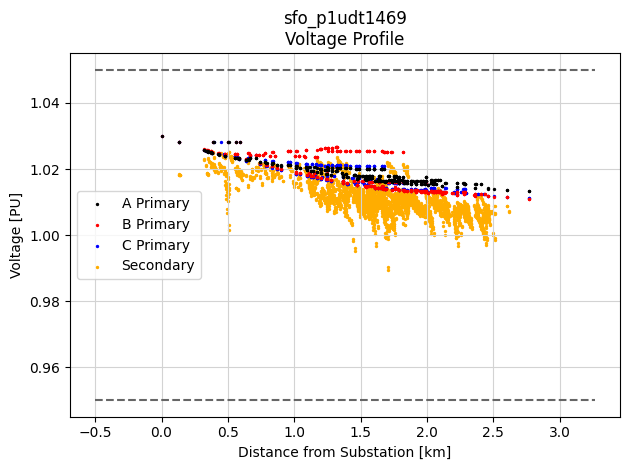

In [11]:
fig, ax = feeder.plot()

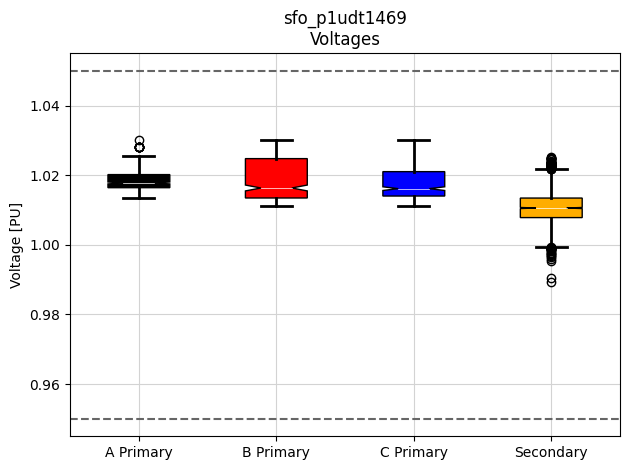

In [12]:
fig, ax = feeder.plot(kind='box')

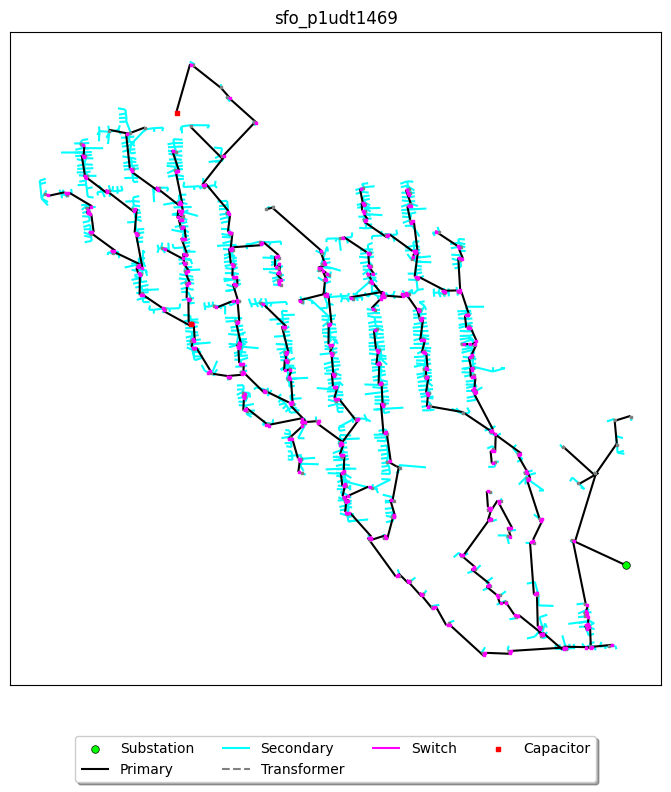

(<Figure size 1100x800 with 1 Axes>, <Axes: title={'center': 'sfo_p1udt1469'}>)

In [13]:
feeder.plot(kind='topo')

# Exporting Feeder GIS
The code below demonstrates how all feeder data could be exported as 
geopackage files.

Note: The expected input and output CRS is the standard 4326 lat/long.

But this can be altered using the input parameters `input_crs` and `output_crs`.


In [14]:
dreams.gis.export_feeder_gpkg(
    feeder,
    output_path=output_dir
)

['models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_buses.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_capacitors.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_fuses.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_lines.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_loads.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_switches.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_transformers.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_voltage_sources.gpkg']

While the above will export all types of GIs data,
 single types of data can also be exported one at a time, or,
(as shown below) not exported, and the resulting GeoDataFrame can be
further utilized Python work flows.

In [15]:
bus_gdf = dreams.gis.export_bus_gis(feeder, export_gpkg=False)
bus_gdf.head()

,name,kv_base,v1,ang1,v2,ang2,v3,ang3,max_v,min_v,...,phases,nodes,distance,primary,over_voltage,under_voltage,p_kw_net,q_kvar_net,s_kva_net,geometry
0,p1udt1469-p1uhs0_1247x,7.199558,1.030000,-0.000019,1.030000,-120.000018,1.030000,119.999982,1.030000,1.030000,...,ABC,123,0.000000,True,False,False,0.0,0.0,0.000000,POINT (-122.39286 37.75422)
1,p1udt1469,7.199558,1.028167,-0.114106,1.028280,-120.105051,1.028219,119.896007,1.028280,1.028167,...,ABC,123,0.131874,True,False,False,0.0,0.0,0.000000,POINT (-122.39398 37.75474)
2,p1udt1469lv,0.277128,1.018261,-0.855974,1.018375,-120.846754,1.018314,119.154215,1.018375,1.018261,...,ABC,123,0.131874,False,False,False,0.0,0.0,0.000000,POINT (-122.39403 37.75476)
3,p1ulv7623,0.277128,1.018145,-0.872343,1.018259,-120.863122,1.018198,119.137851,1.018259,1.018145,...,ABC,123,0.136484,False,False,False,61.9,4.3,62.049174,POINT (-122.39399 37.7547)
4,p1udt940,7.199558,1.025655,-0.271107,1.025936,-120.249150,1.025790,119.753873,1.025936,1.025655,...,ABC,123,0.318832,True,False,False,0.0,0.0,0.000000,POINT (-122.3937 37.7534)


Again, the GeoDataFrames are created using EPSG:4326 as a default CRS, but any
CRS can be passed into `Feeder` class during intialization, or passed into the gis_export function will be
used instead.

In [16]:
bus_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Again, full functaionly of GeoDataFrames is possible.

Text(0.5, 1.0, 'Average Bus Voltage')

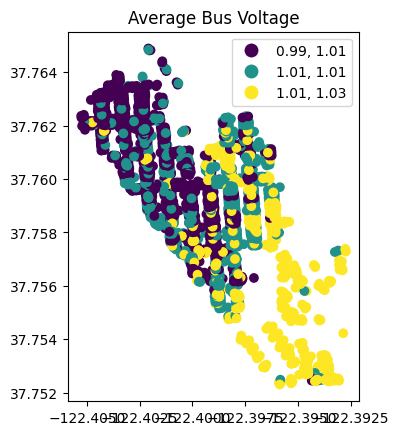

In [17]:
ax = bus_gdf.plot(
    column="ave_v",
    scheme="quantiles",
    k=3,
    cmap="viridis",
    legend=True,
    legend_kwds={'loc': 'upper right'},
    )
ax.set_title('Average Bus Voltage')

This concludes the introduction to DREAMS showing how to:

load a feeder,
look at some feeder statistics and dataframes,
basic plotting, and GIS export functionality.